In [1]:
!pip install requests pandas matplotlib numpy
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
print("✅ Ready!")

✅ Ready!


In [2]:
# Fetch actual wind generation Jan 2024
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2024-01-01&settlementDateTo=2024-01-31&fuelType=WIND&format=json"
data = requests.get(url).json()
df = pd.DataFrame(data)[['startTime', 'generation']]
df.columns = ['time', 'generation']
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
print("✅ Rows:", len(df))
print(df.head())

✅ Rows: 1488
                          time  generation
1487 2024-01-01 00:00:00+00:00       10402
1486 2024-01-01 00:30:00+00:00       10845
1485 2024-01-01 01:00:00+00:00       11218
1484 2024-01-01 01:30:00+00:00       11223
1483 2024-01-01 02:00:00+00:00       11234


In [3]:
# Basic stats
print("=== WIND GENERATION STATS (Jan 2024) ===")
print(f"Mean:   {df['generation'].mean():.0f} MW")
print(f"Median: {df['generation'].median():.0f} MW")
print(f"Min:    {df['generation'].min():.0f} MW")
print(f"Max:    {df['generation'].max():.0f} MW")
print(f"P10:    {df['generation'].quantile(0.10):.0f} MW")
print(f"P25:    {df['generation'].quantile(0.25):.0f} MW")
print(f"P75:    {df['generation'].quantile(0.75):.0f} MW")
print(f"P90:    {df['generation'].quantile(0.90):.0f} MW")

=== WIND GENERATION STATS (Jan 2024) ===
Mean:   9849 MW
Median: 9864 MW
Min:    0 MW
Max:    16662 MW
P10:    5088 MW
P25:    6732 MW
P75:    13105 MW
P90:    14810 MW


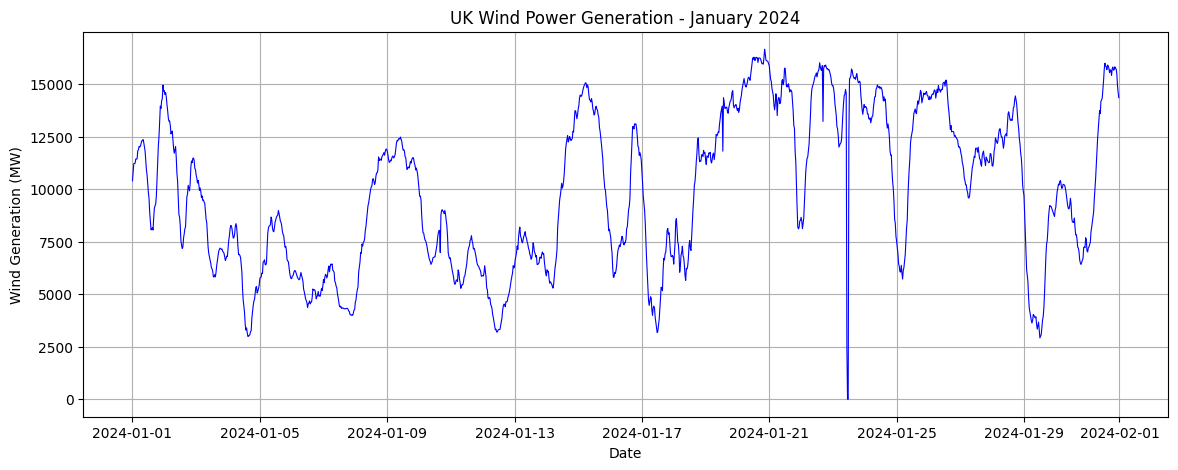

In [4]:
# Plot generation over time
plt.figure(figsize=(14,5))
plt.plot(df['time'], df['generation'], color='blue', linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Wind Generation (MW)')
plt.title('UK Wind Power Generation - January 2024')
plt.grid(True)
plt.show()

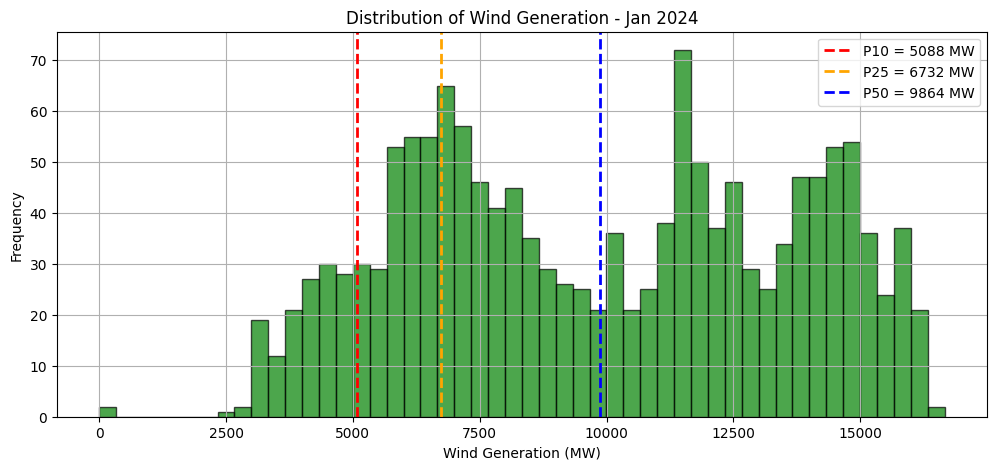

In [5]:
# Distribution + Recommendation
p10 = df['generation'].quantile(0.10)
p25 = df['generation'].quantile(0.25)
p50 = df['generation'].quantile(0.50)

plt.figure(figsize=(12,5))
plt.hist(df['generation'], bins=50, color='green', edgecolor='black', alpha=0.7)
plt.axvline(p10, color='red', linestyle='--', linewidth=2, label=f'P10 = {p10:.0f} MW')
plt.axvline(p25, color='orange', linestyle='--', linewidth=2, label=f'P25 = {p25:.0f} MW')
plt.axvline(p50, color='blue', linestyle='--', linewidth=2, label=f'P50 = {p50:.0f} MW')
plt.xlabel('Wind Generation (MW)')
plt.ylabel('Frequency')
plt.title('Distribution of Wind Generation - Jan 2024')
plt.legend()
plt.grid(True)
plt.show()

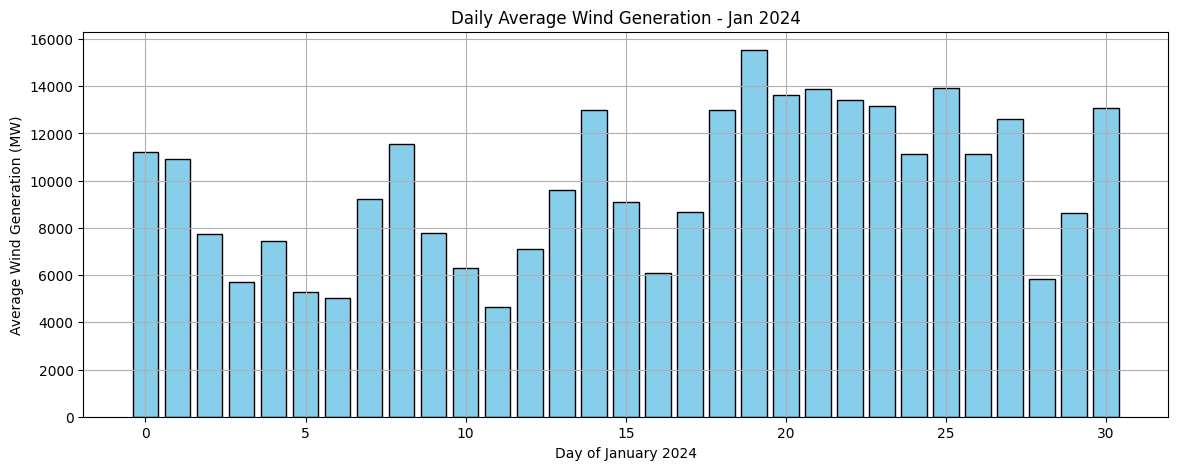

In [6]:
# Daily average
df['date'] = df['time'].dt.date
daily = df.groupby('date')['generation'].mean()

plt.figure(figsize=(14,5))
plt.bar(range(len(daily)), daily.values, color='skyblue', edgecolor='black')
plt.xlabel('Day of January 2024')
plt.ylabel('Average Wind Generation (MW)')
plt.title('Daily Average Wind Generation - Jan 2024')
plt.grid(True)
plt.show()

In [7]:
p10 = df['generation'].quantile(0.10)

print("=" * 50)
print("✅ WIND RELIABILITY RECOMMENDATION")
print("=" * 50)
print(f"""
Based on January 2024 UK wind generation data:

📊 Key Statistics:
- Average generation: {df['generation'].mean():.0f} MW
- Minimum recorded:   {df['generation'].min():.0f} MW
- Maximum recorded:   {df['generation'].max():.0f} MW

🎯 Recommendation:
We can RELIABLY expect {p10:.0f} MW from wind power.

Why P10?
- Wind is available above this level 90% of the time
- Grid planners use P10 as the "firm capacity"
- This is the SAFE number to count on for demand planning

⚠️ Note:
- Wind can drop to near 0 MW in calm periods
- Always maintain backup capacity for low-wind days
""")

✅ WIND RELIABILITY RECOMMENDATION

Based on January 2024 UK wind generation data:

📊 Key Statistics:
- Average generation: 9849 MW
- Minimum recorded:   0 MW  
- Maximum recorded:   16662 MW

🎯 Recommendation:
We can RELIABLY expect 5088 MW from wind power.

Why P10?
- Wind is available above this level 90% of the time
- Grid planners use P10 as the "firm capacity"
- This is the SAFE number to count on for demand planning

⚠️ Note:
- Wind can drop to near 0 MW in calm periods
- Always maintain backup capacity for low-wind days

